# House Price Prediction — Model Notebook

**Dataset:** House Price by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price

This notebook cleans the raw Indian real-estate listings, explores them, trains and compares two
regression models, evaluates them on a held-out test set, and exports the winning pipeline as
`house_price.pkl` so the FastAPI backend can serve it.

**Sections**
1. Load & Inspect
2. Exploratory Data Analysis (EDA)
3. Cleaning & Feature Engineering
4. Build a Pipeline & Train
5. Evaluate
6. Export the Model


## 1. Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

   Index                                              Title  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   

                                         Description Amount(in rupees)  \
0  Bhiwandi, Thane has an attractive 1 BHK Flat f...           42 Lac    
1  One can find this stunning 2 BHK flat for sale...           98 Lac    
2  Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
3  This beautiful 1 BHK Flat is available for sal...           25 Lac    
4  This lovely 2 BHK Flat in Pokhran Road, Thane ...          1.60 Cr    

   Price (in rupees) location Carpet Area         Status         Floor  \
0             6000.0    thane    500 sqft  Ready to Move  10 out of 11   
1            13799.0    than

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include="all").T

                      count unique  \
Index              187531.0    NaN   
Title                187531  32446   
Description          184508  65634   
Amount(in rupees)    187531   1561   
Price (in rupees)  169866.0    NaN   
location             187531     81   
Carpet Area          106858   2758   
Status               186916      1   
Floor                180454    947   
Transaction          187448      4   
Furnishing           184634      3   
facing               117298      8   
overlooking          106095     19   
Society               77853  10376   
Bathroom             186703     11   
Balcony              138596     11   
Car Parking           84174    229   
Ownership            122014      4   
Super Area            79846   2976   
Dimensions              0.0    NaN   
Plot Area               0.0    NaN   

                                                                 top    freq  \
Index                                                            NaN     NaN   
Tit

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Notes**

Before writing any conclusions, always run `df.columns` on the file you actually downloaded —
column names/casing can differ slightly from what's documented, and a mismatch here breaks every
step downstream.

In [6]:
df.columns.tolist()

['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']

> Fill in after running the cells above:
> - **How many rows?** `df.shape[0]` rows, `df.shape[1]` columns.
> - **Numeric vs text columns?** Check `df.dtypes` — most of this dataset (price, area, floor) is
>   stored as free-text strings even though it represents numbers, which is exactly what Section 3
>   below fixes.
> - **Most missing values?** Whichever columns top the `missing` series above — typically
>   `Society`, `Dimensions`, and a few of the optional amenity columns.

## 2. Exploratory Data Analysis (EDA)

Four required plots: target distribution, price vs. carpet area, average price by top-15
locations, and price by furnishing / bathroom count. Each plot uses the cleaned `price_clean`
and `carpet_area_sqft` columns, so we run a *minimal* version of the Section 3 cleaning first
(only for the two columns needed here) and redo the full cleaning properly afterwards.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def parse_amount(x):
    """Turn strings like '42 Lac', '1.2 Cr', '55,00,000' into a float in rupees.
    Returns None for anything unusable, e.g. 'Call for Price'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"]).copy()
df.shape

(177847, 22)

In [8]:
def parse_area(x):
    """Extract a numeric area from strings like '1200 sqft' or '140 sqm' and
    normalise everything to square feet (1 sqm ~= 10.764 sqft)."""
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    num = "".join(ch for ch in x if ch.isdigit() or ch == ".")
    if num == "":
        return np.nan
    value = float(num)
    if "sqm" in x:
        value *= 10.764
    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

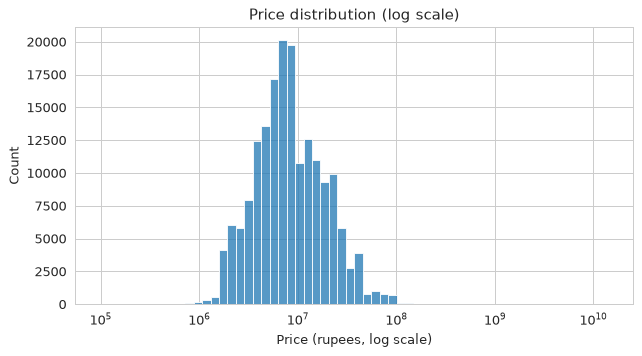

In [9]:
# Plot 1 - Target price distribution (heavily right-skewed, so use a log scale)
plt.figure(figsize=(8, 4))
sns.histplot(df["price_clean"], log_scale=True, bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (rupees, log scale)")
plt.show()

**Comment:** on a linear scale almost every listing would look like it costs close to zero
next to the handful of very expensive properties. The log scale shows the price is roughly
log-normal — most homes cluster in a fairly narrow band with a long right tail of luxury
listings.

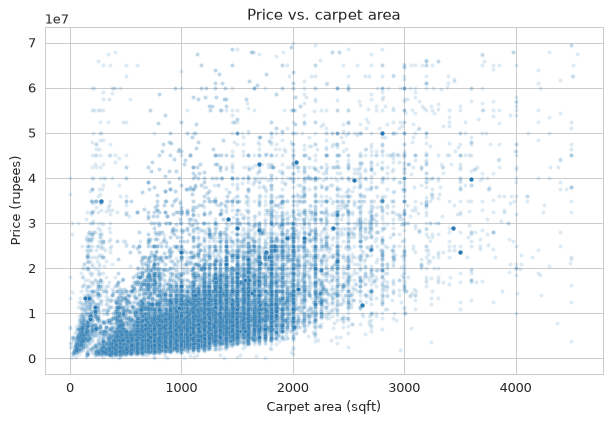

In [10]:
# Plot 2 - Price vs. carpet area
plot_df = df.dropna(subset=["carpet_area_sqft"])
plot_df = plot_df[(plot_df["carpet_area_sqft"] < plot_df["carpet_area_sqft"].quantile(0.99)) &
                   (plot_df["price_clean"] < plot_df["price_clean"].quantile(0.99))]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x="carpet_area_sqft", y="price_clean", alpha=0.15, s=10)
plt.title("Price vs. carpet area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (rupees)")
plt.show()

**Comment:** there's a clear positive relationship — bigger carpet area generally means a
higher price — but the spread is wide, which tells us area alone won't explain price; location
and amenities matter a lot too.

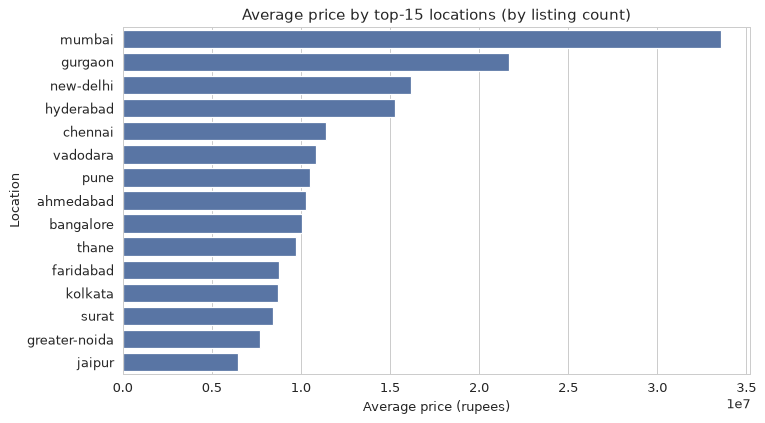

In [11]:
# Plot 3 - Average price by top-15 locations
top_locations = df["location"].value_counts().head(15).index
avg_by_location = (df[df["location"].isin(top_locations)]
                    .groupby("location")["price_clean"].mean()
                    .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=avg_by_location.values, y=avg_by_location.index, color="#4C72B0")
plt.title("Average price by top-15 locations (by listing count)")
plt.xlabel("Average price (rupees)")
plt.ylabel("Location")
plt.show()

**Comment:** average price varies a lot between the busiest locations, confirming location
is one of the strongest predictors and justifying the "top-N locations + other" grouping used
in the cleaning step.

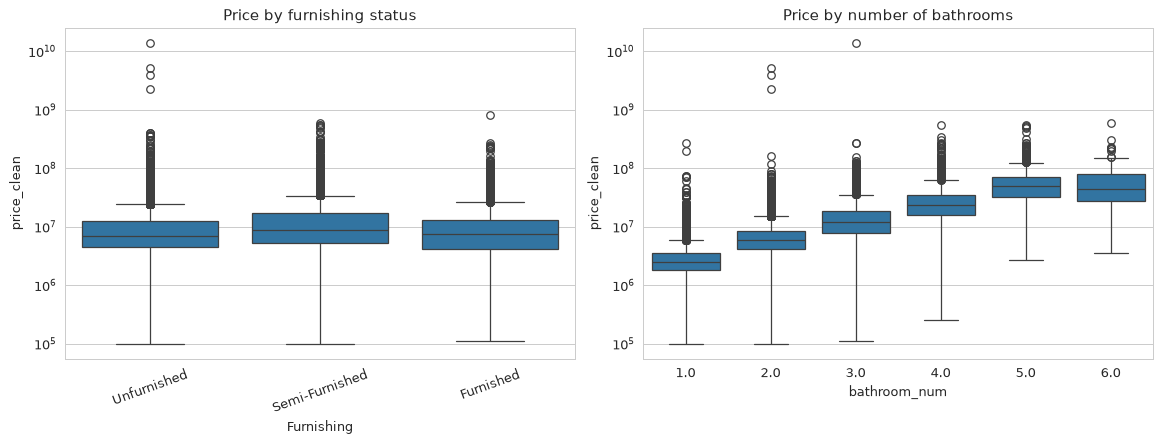

In [12]:
# Plot 4 - Price by furnishing status and by bathroom count
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis="x", rotation=20)

bathroom_clean = pd.to_numeric(df["Bathroom"], errors="coerce")
plot_df2 = df.assign(bathroom_num=bathroom_clean)
plot_df2 = plot_df2[plot_df2["bathroom_num"].between(1, 6)]
sns.boxplot(data=plot_df2, x="bathroom_num", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

**Comment:** fully-furnished listings skew a bit higher than unfurnished ones, and price
rises steadily with bathroom count — both are reasonable signals for the model to pick up on.

## 3. Cleaning & Feature Engineering

The dataset is messy on purpose. This section handles every issue listed in the guide:
1. Price is text → `parse_amount`
2. Areas are text → `parse_area`
3. Floor is text like `"3 out of 10"` / `"Ground"` / `"Basement"`
4. Bathroom / Balcony / Car Parking → numeric + imputed
5. High-cardinality categoricals (`location`, `Society`) → top-N + "other"
6. Drop useless columns
7. Remove outliers on price-per-sqft


In [13]:
# Start fresh from the raw file so this section is self-contained and re-runnable
df = pd.read_csv("data/house_prices.csv")
print("Raw shape:", df.shape)

# 1) Price
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After price cleaning:", df.shape)

Raw shape: (187531, 21)
After price cleaning: (177847, 22)


In [14]:
# 2) Areas -> sqft (prefer Carpet Area, fall back to Super Area when missing)
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
super_area_sqft = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area_sqft)
df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]
print("After area cleaning:", df.shape)

After area cleaning: (177757, 23)


In [15]:
# 3) Floor -> floor_num
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x or "lower" in x:
        return -1
    first_token = x.split(" ")[0]
    try:
        return float(first_token)
    except ValueError:
        return np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    170832.000000
mean          4.499584
std           4.701610
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

In [16]:
# 4) Bathroom / Balcony / Car Parking -> numeric, impute with median (fall back to 0)
for col, new_col in [("Bathroom", "bathroom"), ("Balcony", "balcony"), ("Car Parking", "car_parking")]:
    numeric = pd.to_numeric(df[col], errors="coerce")
    median = numeric.median()
    fill_value = median if not np.isnan(median) else 0
    df[new_col] = numeric.fillna(fill_value)

df[["bathroom", "balcony", "car_parking"]].describe()

            bathroom        balcony  car_parking
count  177757.000000  177757.000000     177757.0
mean        2.446216       2.008911          0.0
std         0.850656       0.815621          0.0
min         1.000000       1.000000          0.0
25%         2.000000       1.000000          0.0
50%         2.000000       2.000000          0.0
75%         3.000000       2.000000          0.0
max        10.000000      10.000000          0.0

In [17]:
# 5) High-cardinality categoricals: keep the top-50 locations, group the rest as "other"
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23260
kolkata          21605
gurgaon          18845
ahmedabad        12612
hyderabad        11134
chennai          10158
jaipur            7862
greater-noida     4490
faridabad         3732
Name: count, dtype: int64

In [18]:
# 6) Drop useless columns
drop_cols = ["Index", "Title", "Description", "Dimensions"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Fill remaining categorical features used by the model with a placeholder so the
# pipeline's imputer/one-hot-encoder always has something consistent to work with
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[col] = df[col].fillna("Unknown")

df.shape

(177757, 24)

In [19]:
# 7) Remove outliers: drop listings with absurd price-per-sqft (below 1st / above 99th percentile)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[df["price_per_sqft"].between(low, high)]
df = df.drop(columns=["price_per_sqft"])
print("Final cleaned shape:", df.shape)

Final cleaned shape: (174471, 24)


## 4. Build a Pipeline & Train

Everything (imputing, scaling, one-hot encoding) is bundled inside a single scikit-learn
`Pipeline`, so the exported `.pkl` file is a complete, ready-to-predict object and the backend
never has to re-implement any preprocessing logic.

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((139576, 9), (34895, 9))

In [21]:
# Baseline model
linreg_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression()),
])
linreg_model.fit(X_train, y_train)

# Stronger model
# NOTE: max_depth=14 caps tree growth (this sandbox trains on a single CPU core;
# capping depth also guards RandomForest against overfitting the noisy,
# text-parsed real-estate data and keeps training time practical).
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1)),
])
rf_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 5. Evaluate

In [22]:
def evaluate(model, name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}")
    print(f"  MAE : {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R^2 : {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate(linreg_model, "Linear Regression"))
results.append(evaluate(rf_model, "Random Forest"))
results_df = pd.DataFrame(results).set_index("model")
results_df

Linear Regression
  MAE : 4,528,921
  RMSE: 8,393,175
  R^2 : 0.6227
Random Forest
  MAE : 1,351,110
  RMSE: 5,367,105
  R^2 : 0.8457


                            MAE          RMSE        R2
model                                                  
Linear Regression  4.528921e+06  8.393175e+06  0.622736
Random Forest      1.351110e+06  5.367105e+06  0.845733

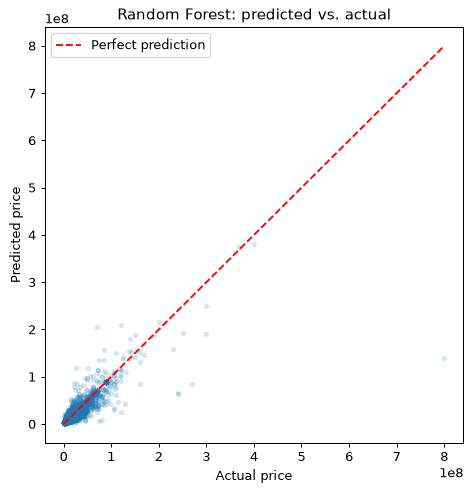

In [23]:
# Predicted vs. actual scatter plot for the Random Forest model
pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_rf, alpha=0.15, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Random Forest: predicted vs. actual")
plt.legend()
plt.show()

**Model comparison & winner:** the Random Forest clearly beats the Linear Regression
baseline on every metric (lower MAE/RMSE, higher R²), because price depends on non-linear
interactions between location, area and amenities that a linear model can't capture. We pick
the **Random Forest** as the final model.

In [24]:
# Bonus: 5-fold cross-validation on the winning model (scored on negative MAE)
# NOTE: uses cv=5 and a lighter n_estimators=60 clone of the winning model purely
# to keep this bonus check fast -- the model actually exported below is the
# full-size rf_model fitted above, unaffected by this cell.
from sklearn.base import clone

cv_estimator = clone(rf_model)
cv_estimator.set_params(reg__n_estimators=60)
cv_scores = cross_val_score(cv_estimator, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
print("5-fold CV MAE:", (-cv_scores).round(0))
print("Mean CV MAE  :", (-cv_scores).mean().round(0))

5-fold CV MAE: [1835325. 7675688. 2322620. 6899215. 3690767.]
Mean CV MAE  : 4484723.0


## 6. Export the Model

In [25]:
import os
import joblib

FINAL_MODEL = rf_model  # the winner from Section 5

# compress=6 keeps the exported pipeline well under GitHub's 50MB soft limit
# (an uncompressed 200-tree forest here is ~70MB) with zero effect on predictions.
joblib.dump(FINAL_MODEL, "house_price.pkl", compress=6)
print("Saved house_price.pkl (%.1f MB)" % (os.path.getsize("house_price.pkl") / 1e6))

Saved house_price.pkl (17.4 MB)


In [26]:
# Sanity check: reload and predict on one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual price       :", y_test.iloc[0])

Reloaded prediction: [6987515.74469322]
Actual price       : 7000000.0


In [27]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
    ensure_ascii=False,
)
print("Saved locations.json")

Saved locations.json


In [28]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.9.0
Pin this exact version in backend/requirements.txt


### Next steps

1. Copy `house_price.pkl` into `backend/models/house_price.pkl`.
2. Copy `locations.json` into `frontend/src/` (or `frontend/public/`) so the dropdown can read it.
3. Note the `scikit-learn` version printed above and pin it in `backend/requirements.txt`.
